## Load Functions

In [1]:
import numpy as np
import pickle
import matplotlib.pyplot as plt
import os
import matplotlib.colors as colors
import time

In [2]:
def Marchenko_Pastur_significance_threshold(lam,var):
    sqrt = np.sqrt(lam)
    out1 = var*(1-sqrt)**2
    out2 = var*(1+sqrt)**2
    return (out1,out2)
    
def Marchenko_Pastur_distribution(lambda_min,lambda_max,lam,var):
    x_vector = np.linspace(lambda_min,lambda_max,10000)
    dx = x_vector[1]-x_vector[0]
    pdf = 1/(2*np.pi*var) * np.sqrt((lambda_max-x_vector)*(x_vector-lambda_min))/(lam*x_vector)
    return x_vector,pdf

In [3]:
def plot_matrix(matrix,cmap = 'RdBu',max_value=None,min_value=None,aspect=None,tight_layout=True,figsize=None,
               xticks = [],x_ticklabels = [],x_orientation=0,x_alignment='center',
                yticks = [],y_ticklabels = [],title=None,
               xlabel=None,ylabel=None,
                set_log_xscale=False,set_log_yscale=False,scale=None,
               cbar_label = None,x_fontsize=10,y_fontsize=10,
               savefig=False,out_dir='',data_name = '',
               draw_special_diagonal=False,diagonal_color='k'):

    if max_value==None:
        max_value = 1.1*np.max(matrix)
    if min_value==None:
        min_value = 1.1*np.min(matrix)
    norm_value = (colors.TwoSlopeNorm(vcenter=0,vmin=min_value,vmax=max_value) if cmap=='RdBu' else None)
    if scale=='log': norm_value='log'
    fig,ax = plt.subplots(figsize=figsize)
    heatmap = ax.imshow(
               matrix,
               cmap=cmap,
               aspect=aspect,
               norm=norm_value,
               vmax = (max_value if cmap=='Reds' or cmap=='Blues' else None),
                       )
    cbar = fig.colorbar(heatmap,label=cbar_label)
    if draw_special_diagonal ==True:
        for i in range(min(np.shape(matrix)[0],np.shape(matrix)[1])):
            rect = patches.Rectangle(
                (i - 0.5, i - 0.5),  # bottom-left corner (cell boundaries in imshow coordinates)
                1, 1,                # width, height (one cell)
                facecolor="black",
                edgecolor="none",
                zorder=3             # draw above the image
            )
            ax.add_patch(rect)
    ax.set_xticks(xticks)
    ax.set_yticks(yticks)
    ax.set_yticklabels(y_ticklabels,fontsize=y_fontsize)
    ax.set_xticklabels(x_ticklabels,rotation=x_orientation,ha=x_alignment,
                      fontsize=x_fontsize)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title(title)
    if set_log_xscale == True:
        ax.set_xscale('log')
    if set_log_yscale==True:
        ax.set_yscale('log')
    if tight_layout==True:
        plt.tight_layout()
    if savefig==True:
        plt.savefig(os.path.join(out_dir,data_name)+str('.png'),format='png',dpi=200)
    plt.show()  

    return

In [4]:
from numba import njit

@njit
def species_growth_rates(R_vec,n_vec,
                 growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                ):
    ''' Growth of the species as a function of the resource abundances: g_i^\alpha(\vec{R},\vec{n})
    By default, we use nR/(1+R) on all resources.
    '''
    R_part = R_vec/(1+R_vec)
    outer = np.outer(R_part,n_vec) #Shape (N_R,N_n)
    outer = outer*growth_choices
    
    # if np.random.random()<1e-3:
    #     print('growth_rates',np.sum(outer>1e-3))
    #     print(outer[0,:])

    ''' Calculate also the total species growth rates '''
    species_total_growth_rate = np.sum(outer,axis=0) #shape (N_species)
    return outer,species_total_growth_rate

@njit
def resource_depletion_production(R_vec,n_vec,
                   total_species_growth_rate, #Shape (N_species)
                                  inv_yields):

    '''
    Calculates g_i^alpha*1/Y_i^\alpha
    '''

    resource_changes = total_species_growth_rate[None,:]*inv_yields #is shape (1,N_res,N_species). I don't know why there is the one

    # if np.random.random()<1e-3:
    #     print('production terms',resource_changes)
    
    return resource_changes

@njit
def d_resources(R_vec,n_vec,
               entry_rates,
                total_growth_rates,
                inv_yields):

    entry = entry_rates #shape (N_res)
    res_changes = resource_depletion_production(R_vec,n_vec,total_growth_rates,inv_yields)

    # if np.random.random()<1e-3:
    #     print('res_changes',res_changes)

    consumption_production = -np.sum(res_changes,axis=1) #Shape N_resource

    return entry+consumption_production

@njit
def d_species(n_vec,growth_rates):

    species_growth = np.sum(growth_rates,axis=0)

    return species_growth    
    
    
    
    

In [5]:
dataset_name = 'out'
if os.path.exists(dataset_name)==False:
    os.mkdir(dataset_name)

In [6]:
''' System constants '''
N_species = 20
N_resources = 3
independent_species_cutoff = 20 #N_species #species beyond this cutoff exist independently of all others and are akin to noise
nsteps = 20000
nsteps = 10000
dt = 0.01
dilution = 0.1

In [7]:
noise_levels = np.linspace(1e-1,3,50)


## Set up and run simulations. Not needed, go straight to data analysis.

In [ ]:


''' Resource entries '''
entry_rates = np.zeros(N_resources)
how_many_suplied_resources = int(np.round(N_resources/5)+1e-4)
how_many_supplied_resources = N_resources
how_many_supplied_resources = 2
entered_res = np.random.choice(min(independent_species_cutoff,N_resources),
                               size=how_many_supplied_resources,
                               replace=False)
# entered_res = np.random.choice(20,size=how_many_supplied_resources,replace=False)
entry_rates[entered_res] = np.abs(np.random.normal(0,1,size=len(entered_res))) #gaussian(0,1) 
if independent_species_cutoff<N_resources:
    entry_rates[independent_species_cutoff:] = np.abs(np.random.normal(0,1,size=N_species-independent_species_cutoff))#such that independent species also grow, in the absence of interactions with others.
# entry_rates[:independent_species_cutoff] = 1 #to make all species the same for the independent dataset


''' Inverse yields and growth preferences '''
inv_yields = np.zeros((N_resources,N_species))#np.random.normal(0,1,N_resources*N_species).reshape((N_resources,N_species))
growth_choices = np.zeros((N_resources,N_species))
for sp in range(N_species):

    
    if sp<independent_species_cutoff:
        
        eats_single_resource = True
        if eats_single_resource:
            ''' If eating one resource '''
            # res = np.random.choice(independent_species_cutoff) #if random
            res = sp%N_resources #if non-random
            # res = sp//5 #if guilded
            res = sp//7 #if dividing into 3 yields as in the CR-batch simulation
            # growth_choices[res,sp] = 1.0 #species eats the chosen resource
            inv_yields[res,sp] = 1.0 #consumption yield. You can add some small gaussian noise to make them different.
            growth_choices[res,sp] = 1.0 #species eats the chosen resource
        else:
            ''' If eating multiple resources '''
            how_many_res_eaten = 4-1
            eaten_resources = np.random.choice(sp,size= min(how_many_res_eaten,sp),replace=False)
            growth_choices[eaten_resources,sp] = 1.0
            inv_yields[eaten_resources,sp] = 1.0
            growth_choices[sp,sp] = 1.0; inv_yields[sp,sp] = 1.0
    else:
        res = sp%N_resources
        growth_choices[res,sp] = 1.0 #species eats the chosen resource
        inv_yields[res,sp] = 1.0 #consumption yield
    
   
    
    

    
    if sp>=independent_species_cutoff:
        ''' For independent species, give them a yield that makes them scale across several orders of magnitude '''
        if independent_species_cutoff<N_resources:
            inv_yields[res,sp] = 10**(2*np.random.random()) #to make independent species span several orders of magnitude
        else:
            inv_yields[res,sp] = 1.0 #all independent species have the same yield. You can then rescale their abundances to match other species abundances.

    if sp<independent_species_cutoff:
        # produceable_species = np.delete(np.arange(N_species),res) #select from all resources except the eaten one
        # produceable_species = np.arange(res+1,res+independent_species_cutoff) #select from the next resources, wrt to eaten resource, in the network
        # produceable_species = np.arange(sp+1,min(sp+independent_species_cutoff,N_species)) #select from the next resources, wrt species, in the network
        # produceable_species = [(res+1)%N_resources] #produce only next resource
        # produceable_species = np.arange(res+1,min(res+N_resources,N_resources)) #for 2025.10.22
        # produceable_species = [res+1] if res<N_resources-1 else []
        # produceable_species = np.arange((sp//5+1),
        #                                 # N_resources #produces any resources downstream
        #                                 (sp//5+6), #produces only from amongst the next 5 resources
        #                                )
        produceable_species = [2] if sp//7<2 else []
        
        if len(produceable_species)>0:
            how_many_secreted_resources = 1
            produced_res = np.random.choice(produceable_species,size=how_many_secreted_resources,
                                           ) #Resources produced by the species
            produced_res = produced_res[produced_res<N_resources]
            produced_res = produced_res%N_resources
            
            # produced_res = produced_res[produced_res<independent_species_cutoff] #cannot produce resources that have no corresponding species
            inv_yields[produced_res,sp] = -0.5*1/how_many_secreted_resources #-0.5 #resource is produced
        




In [56]:
inv_yields_complete = np.copy(inv_yields)
growth_choices_complete = np.copy(growth_choices)

''' Dump these arrays to they can be loaded from the functions.py file '''

with open('inv_yields_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(inv_yields_complete,f)
    f.close()
with open('growth_choices_complete.{}.dat'.format(dataset_name),'wb') as f:
    pickle.dump(growth_choices_complete,f)
    f.close()

In [60]:
sim_number = 1

N_sims = 100 #100 simulations per noise level

lowest_eigenvalues = []
all_eigenvalues = []
angles = []
for ii,noise_level in enumerate(noise_levels):
    dataset = []
    for sim in range(N_sims):
        print('{}.{}'.format(ii,sim))

        species_abus = np.random.random(N_species)
        resource_abus = np.random.random(N_resources)
        
        res_noise_weights = 1e-5#np.linspace(1e-5,1e-1,N_resources) #this way there are different noise levels for different resource-mediated interactions
        
        
        species_traces_full = []
        resource_traces_full = []
    
        ''' Resource entries. Supplied resources are always the same, but their entry rates are random. '''
        
        
        entry_rates = np.random.random(3)*10
        entry_rates[2] = 0 #input only first two resources, 3rd is cross-fed
        
        species_abus = np.random.random(N_species)
        resource_abus = np.random.random(N_resources)
        
    
        time0 = time.time()
    
    
        ''' Prepare colored noise ''' 
        sigma_outside = 1
        sigma_inside = noise_level
        
        
        for step in range(nsteps):
            # if step%1000==0: print('{:.3f}%'.format(step/nsteps*100))
            species_traces_full.append(np.copy(species_abus))
            resource_traces_full.append(np.copy(resource_abus))
            
        
            
            ''' Growth rates '''
            growth_rates,total_growth_rate_per_species = species_growth_rates(resource_abus,species_abus,
                         growth_choices #Shape (N_R,N_n) matrix of 1s and 0s indicating resources being consumed. At most one resource is consumed per species.
                        )
            
            
            
            d_res = d_resources(resource_abus,species_abus,
                       entry_rates,
                                total_growth_rate_per_species,
                       inv_yields)-resource_abus*dilution
            
            d_sp = d_species(species_abus,growth_rates)-species_abus*dilution
            sp_noise = np.random.normal(0,0.1,size=(N_species))*np.sqrt(dt)
            
            species_abus += d_sp*dt +sp_noise
    
                      
    
            thres = 1e-10
            
            ''' WHite noise '''
            outside_resource_noise = np.random.normal(0,sigma_outside,size=(N_resources))*np.sqrt(dt)*(entry_rates>=thres) #noise for supplied resources is large
            inside_resource_noise = np.random.normal(0,sigma_inside,size=(N_resources))*np.sqrt(dt)*(entry_rates<thres) #noise for cross-fed resources is small
            
            
            outside_resource_noise[resource_abus<thres] = 0
            inside_resource_noise[resource_abus<thres] = 0
    
           
            resource_abus += d_res*dt+outside_resource_noise+inside_resource_noise
            resource_abus[resource_abus<thres] = 0
            species_abus[species_abus<thres] = 0
        resource_traces_full = np.array(resource_traces_full)
        species_traces_full = np.array(species_traces_full)

        final_species_abundances = species_traces_full[-1,:] #keep final species abundances.
        dataset.append(final_species_abundances)


    dataset = np.array(dataset)


    ''' Perform PC analysis to get lowest eigenvalue. '''
    means = np.mean(dataset,axis=0)
    stds = np.std(dataset,axis=0)
    
    corr = np.corrcoef(dataset.T)
    
    eigvals,eigvects = np.linalg.eigh(corr)
    
    argsort = np.argsort(eigvals)
    eigvals = eigvals[argsort]
    eigvects = eigvects[:,argsort]
    
    PC_last = eigvects[:,0]
    lowest_eigenvalue = eigvals[0]

    lowest_eigenvalues.append(lowest_eigenvalue)
    all_eigenvalues.append(eigvals)
    
    ''' Rescale inverse yields appropriately '''
    rescaled_inv_yields = inv_yields[2]*stds
    rescaled_inv_yields = rescaled_inv_yields/np.sqrt(np.sum(rescaled_inv_yields**2))
    
    
    angle = np.arccos(np.dot(PC_last,rescaled_inv_yields))*360/(2*np.pi)
    if angle>90:
        angle = 180-angle
    print('angle',angle,'degrees')
    angles.append(angle)

0.0
0.1
0.2
0.3
0.4
0.5
0.6
0.7
0.8
0.9
0.10
0.11
0.12
0.13
0.14
0.15
0.16
0.17
0.18
0.19
0.20
0.21
0.22
0.23
0.24
0.25
0.26
0.27
0.28
0.29
0.30
0.31
0.32
0.33
0.34
0.35
0.36
0.37
0.38
0.39
0.40
0.41
0.42
0.43
0.44
0.45
0.46
0.47
0.48
0.49
0.50
0.51
0.52
0.53
0.54
0.55
0.56
0.57
0.58
0.59
0.60
0.61
0.62
0.63
0.64
0.65
0.66
0.67
0.68
0.69
0.70
0.71
0.72
0.73
0.74
0.75
0.76
0.77
0.78
0.79
0.80
0.81
0.82
0.83
0.84
0.85
0.86
0.87
0.88
0.89
0.90
0.91
0.92
0.93
0.94
0.95
0.96
0.97
0.98
0.99
angle 1.2835027389088225 degrees
1.0
1.1
1.2
1.3
1.4
1.5
1.6
1.7
1.8
1.9
1.10
1.11
1.12
1.13
1.14
1.15
1.16
1.17
1.18
1.19
1.20
1.21
1.22
1.23
1.24
1.25
1.26
1.27
1.28
1.29
1.30
1.31
1.32
1.33
1.34
1.35
1.36
1.37
1.38
1.39
1.40
1.41
1.42
1.43
1.44
1.45
1.46
1.47
1.48
1.49
1.50
1.51
1.52
1.53
1.54
1.55
1.56
1.57
1.58
1.59
1.60
1.61
1.62
1.63
1.64
1.65
1.66
1.67
1.68
1.69
1.70
1.71
1.72
1.73
1.74
1.75
1.76
1.77
1.78
1.79
1.80
1.81
1.82
1.83
1.84
1.85
1.86
1.87
1.88
1.89
1.90
1.91
1.92
1.93
1.94
1.95
1.96
1.

In [61]:
with open('lowest_eigenvals.dat','wb') as f:
    pickle.dump(lowest_eigenvalues,f)
    f.close()

## Data Analysis

In [8]:
with open('lowest_eigenvals.dat','rb') as f:
    lowest_eigenvalues = pickle.load(f)
    f.close()

In [47]:
if False:
    with open('lowest_eigenvals.allnoiseschange.dat','wb') as f:
        pickle.dump(lowest_eigenvalues,f)
        f.close()

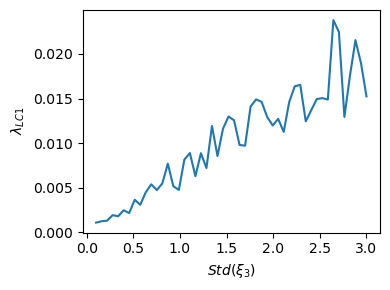

In [10]:
fig, ax = plt.subplots(figsize=(4,3))
ax.plot(noise_levels,
        lowest_eigenvalues)
ax.set_xlabel(r'$Std(\xi_3)$')
ax.set_ylabel(r'$\lambda_{LC1}$')
plt.tight_layout()
plt.savefig('low_variance_eigenvalue_scaling_with_noise.png',format='png',dpi=300)
plt.savefig('low_variance_eigenvalue_scaling_with_noise.svg',format='svg')